<a href="https://colab.research.google.com/github/DianaM38/ClonGoogle/blob/main/MD_KNN_CLASIF_2047960.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CLASIFICACIÓN, APRENDIZAJE SUPERVISADO Y NO SUPERVISADO

Aprendizaje supervisado: subcategoría del machine learning e inteligencia artificial.
Se define por su uso de conjuntos de datos etiquetados para entrenar algoritmos que clasifican datos o predicen resultados.
Amedidaquelos datos de entrada se introducen en el modelo, este adecua su peso hasta que el modelo se halla ajustado apropiadamente.

utiliza muestras de entrenamiento para enseñarle al modelo lo que se desea sea el resultado.
Los dataset de entrenamiento incluyen entradas y salidas correctas que permiten que el modelo aprenda conel tiempo.
El algoritmo mide su precisión a través de la función de pérdida, ajustándose hasta que el error se ha minimizado lo suficiente.
Se puede separar en 2 tipos:

Clasificación:

Utiliza un algoritmo para asignar con precisión los datos en categorías especificas. Reconoce entidades especificas del dataset e intenta a llegar conclusiones en como estas entidades deberían ser etiquetadas o definidas.

*   KNN-k-nearestneighbor
*   Clasificadores lineales
*   Arboles de decisión
*   Randomforest
*   Redes neuronales
*   Naive Bayes
*   SVM-support vector machines



Regresiones: Lineales, logísticas, polinomiales.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap


In [6]:
df = pd.read_csv('Anuncios_SocialMedia.csv')
print(df.shape)
df.head(5)

(400, 3)


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [10]:
x =df.iloc[:,:-1].values
y= df.iloc[:,-1].values
print(x.shape)
print(y.shape)
# df.iloc[:, :-1]  -> Selecciona todas las filas y todas las columnas hasta la penúltima
# df.iloc[:, -1]   -> Selecciona todas las filas y solo la última columna


(400, 2)
(400,)


In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=0,test_size=0.25)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
print(x_train)
print(x_test)
print(y_train)
print(y_test)

(300, 2)
(100, 2)
(300,)
(100,)
[[    44  39000]
 [    32 120000]
 [    38  50000]
 [    32 135000]
 [    52  21000]
 [    53 104000]
 [    39  42000]
 [    38  61000]
 [    36  50000]
 [    36  63000]
 [    35  25000]
 [    35  50000]
 [    42  73000]
 [    47  49000]
 [    59  29000]
 [    49  65000]
 [    45 131000]
 [    31  89000]
 [    46  82000]
 [    47  51000]
 [    26  15000]
 [    60 102000]
 [    38 112000]
 [    40 107000]
 [    42  53000]
 [    35  59000]
 [    48  41000]
 [    48 134000]
 [    38 113000]
 [    29 148000]
 [    26  15000]
 [    60  42000]
 [    24  19000]
 [    42 149000]
 [    46  96000]
 [    28  59000]
 [    39  96000]
 [    28  89000]
 [    41  72000]
 [    45  26000]
 [    33  69000]
 [    20  82000]
 [    31  74000]
 [    42  80000]
 [    35  72000]
 [    33 149000]
 [    40  71000]
 [    51 146000]
 [    46  79000]
 [    35  75000]
 [    38  51000]
 [    36  75000]
 [    37  78000]
 [    38  61000]
 [    60 108000]
 [    20  82000]
 [    57  74000]

In [17]:
ss = StandardScaler()
X_train = ss.fit_transform(x_train)
X_test = ss.transform(x_test)
print(X_train)
print(X_test)

[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]
 [ 1.47293972  0.99784738]
 [ 0.08648817 -0.79972756]
 [-0.01254409 -0.24885782]
 [-0.21060859 -0.5677824 ]
 [-0.21060859 -0.19087153]
 [-0.30964085 -1.29261101]
 [-0.30964085 -0.5677824 ]
 [ 0.38358493  0.09905991]
 [ 0.8787462  -0.59677555]
 [ 2.06713324 -1.17663843]
 [ 1.07681071 -0.13288524]
 [ 0.68068169  1.78066227]
 [-0.70576986  0.56295021]
 [ 0.77971394  0.35999821]
 [ 0.8787462  -0.53878926]
 [-1.20093113 -1.58254245]
 [ 2.1661655   0.93986109]
 [-0.01254409  1.22979253]
 [ 0.18552042  1.08482681]
 [ 0.38358493 -0.48080297]
 [-0.30964085 -0.30684411]
 [ 0.97777845 -0.8287207 ]
 [ 0.97777845  1.8676417 ]
 [-0.01254409  1.25878567]
 [-0.90383437  2.27354572]
 [-1.20093113 -1.58254245]
 [ 2.1661655  -0.79972756]
 [-1.39899564 -1.46656987]
 [ 0.38358493  2.30253886]
 [ 0.77971394  0.76590222]
 [-1.00286662 -0.30684411]
 [ 0.08648817  0.76590222]
 

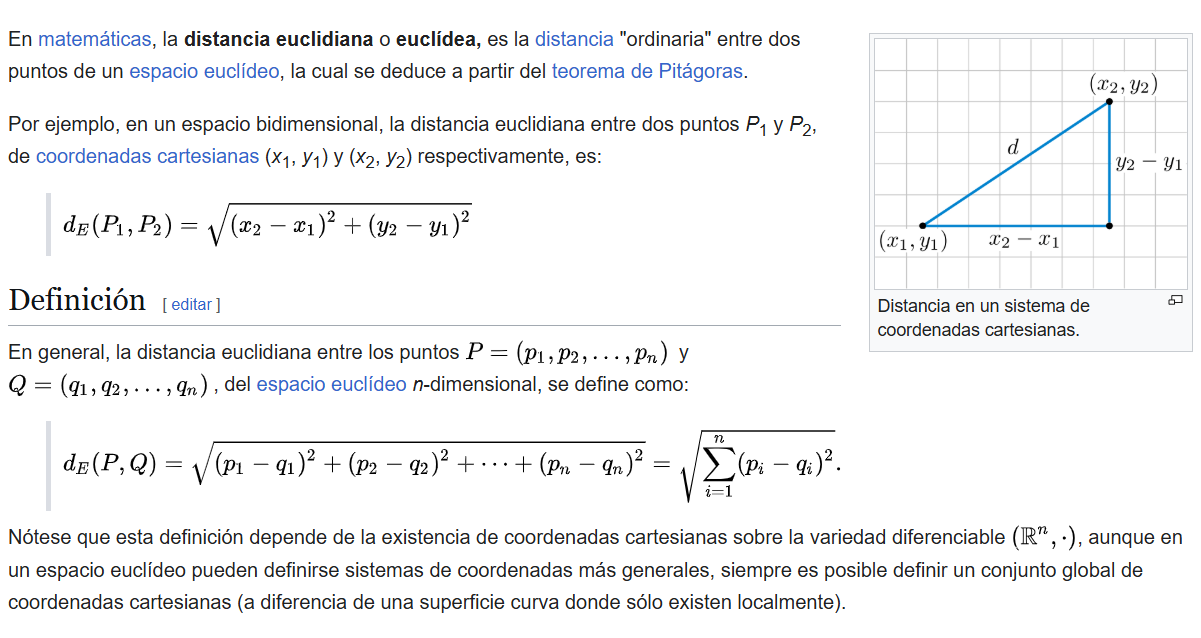

#KNN-k-nearestneighbor
clasifica los puntos de datos basados en su proximidad y asociación con otros datos disponibles.

Asume que puntos de datos similares se pueden encontrar cerca unos deotros. Busca calcular la distancia entre los puntos de datos, usualmente mediante la distancia Euclidiana.

Su desventaja es que a medida que crece el conjunto de prueba, el tiempo de procesamiento se alarga. KNN se usa típicamente para motores de recomendación y reconocimiento de imágenes.

Pasos:
*   Elegimos el numero K de “vecinos”
*   Tomamos el K “vecinos” mas cercano del nuevo punto de datos, acorde a la distancia euclidiana o la metrica que usemos
*   Entre los K “vecinos”, contar el numero de puntos en cada categoría
*   Asignar el nuevo punto de datos en la categoría donde hubo mas“vecinos”
*   Modelo listo


In [19]:
modelo = KNeighborsClassifier(n_neighbors= 5, metric = 'minkowski',p=2)
modelo.fit(X_train,y_train)

KNeighborsClassifier()

In [25]:
print(modelo.predict(ss.transform([[33,150000]])))
y_pred = modelo.predict(X_test)
print(np.concatenate((y_pred.reshape(-1, 1), y_test.reshape(len(y_test), 1)), axis=1))

[1]
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]]


In [29]:
cm= confusion_matrix(y_test,y_pred)
print(cm)
print(accuracy_score(y_test,y_pred))

[[64  4]
 [ 3 29]]
0.93


verdaderos positivos | falsos positivos

---------------------------------
falsos negativos   |    verdaderos negativos

/tmp/ipykernel_13443/1895308623.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j,0], X_set[y_set==j,1],c=ListedColormap(('red','green'))(i),label=j)


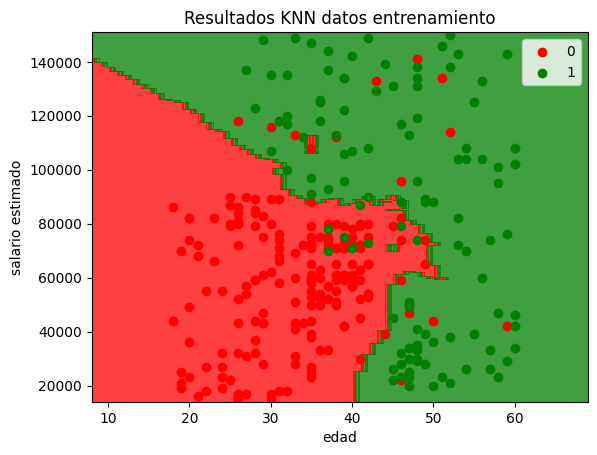

In [38]:
X_set,y_set = ss.inverse_transform(X_train),y_train
x1,x2 =np.meshgrid(np.arange(start=X_set[:,0].min()-10, stop= X_set[:,0].max()+10,step=1),
                     np.arange(start=X_set[:,1].min()-1000, stop= X_set[:,1].max()+1000,step=1))
plt.contourf(x1,x2,modelo.predict(ss.transform(np.array([x1.ravel(),x2.ravel()]).T)).reshape(x1.shape),alpha=0.75,cmap=ListedColormap(('red','green')))
plt.xlim(x1.min(),x1.max())
plt.ylim(x2.min(),x2.max())

for i, j in enumerate(np.unique(y_set)):
  plt.scatter(X_set[y_set == j,0], X_set[y_set==j,1],c=ListedColormap(('red','green'))(i),label=j)

plt.title('Resultados KNN datos entrenamiento')
plt.xlabel('edad')
plt.ylabel('salario estimado')
plt.legend()
plt.show()

/tmp/ipykernel_13443/3080291042.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j,0], X_set[y_set==j,1],c=ListedColormap(('red','green'))(i),label=j)


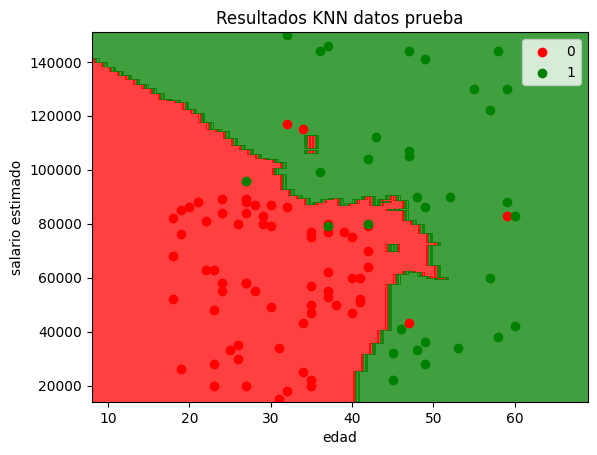

In [39]:
X_set,y_set = ss.inverse_transform(X_test),y_test
x1,x2 =np.meshgrid(np.arange(start=X_set[:,0].min()-10, stop= X_set[:,0].max()+10,step=1),
                     np.arange(start=X_set[:,1].min()-1000, stop= X_set[:,1].max()+1000,step=1))
plt.contourf(x1,x2,modelo.predict(ss.transform(np.array([x1.ravel(),x2.ravel()]).T)).reshape(x1.shape),alpha=0.75,cmap=ListedColormap(('red','green')))
plt.xlim(x1.min(),x1.max())
plt.ylim(x2.min(),x2.max())

for i, j in enumerate(np.unique(y_set)):
  plt.scatter(X_set[y_set == j,0], X_set[y_set==j,1],c=ListedColormap(('red','green'))(i),label=j)

plt.title('Resultados KNN datos prueba')
plt.xlabel('edad')
plt.ylabel('salario estimado')
plt.legend()
plt.show()